In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# setting display options so dataframes are readable
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
print("imports done")

imports done


In [18]:
import os

#auto-detect-enviornment - works in both Colab and VS Code
try:
    from google.colab import drive
    drive.mount('/content/drive')
    data_path = '/content/drive/MyDrive/ML/stock-lens/data/'
    print("running in Colab")
except ImportError:
    data_path = 'data/'
    print("running locally")

os.makedirs(data_path, exist_ok=True)
print("data path:", data_path)

running locally
data path: data/


In [19]:
kaggle_files = ['prices-split-adjusted.csv', 'fundamentals.csv', 'securities.csv', 'prices.csv']
files_exist = all(os.path.exists(data_path + f) for f in kaggle_files)

if not files_exist:
    os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'
    os.environ['KAGGLE_KEY']      = 'your_api_key'
    os.system('pip install kaggle -q')
    os.system(f'kaggle datasets download -d dgawlik/nyse -p {data_path} --unzip')
    print("download complete")
else:
    print("files already present — skipping download")

# loading all three datasets
prices       = pd.read_csv(data_path + 'prices-split-adjusted.csv', parse_dates=['date'])
fundamentals = pd.read_csv(data_path + 'fundamentals.csv')
securities   = pd.read_csv(data_path + 'securities.csv')

print("\nprices shape:      ", prices.shape)
print("fundamentals shape:", fundamentals.shape)
print("securities shape:  ", securities.shape)
print("\ndate range:", prices['date'].min(), "to", prices['date'].max())
print("unique tickers:", prices['symbol'].nunique())

files already present — skipping download

prices shape:       (851264, 7)
fundamentals shape: (1781, 79)
securities shape:   (505, 8)

date range: 2010-01-04 00:00:00 to 2016-12-30 00:00:00
unique tickers: 501


In [20]:
# loading the annual financial metrics from SEC 10-K filings
fundamentals = pd.read_csv(data_path + 'fundamentals.csv')

print("shape:", fundamentals.shape)
print("\ncolumns:", fundamentals.columns.tolist())
fundamentals.head()

shape: (1781, 79)

columns: ['Unnamed: 0', 'Ticker Symbol', 'Period Ending', 'Accounts Payable', 'Accounts Receivable', "Add'l income/expense items", 'After Tax ROE', 'Capital Expenditures', 'Capital Surplus', 'Cash Ratio', 'Cash and Cash Equivalents', 'Changes in Inventories', 'Common Stocks', 'Cost of Revenue', 'Current Ratio', 'Deferred Asset Charges', 'Deferred Liability Charges', 'Depreciation', 'Earnings Before Interest and Tax', 'Earnings Before Tax', 'Effect of Exchange Rate', 'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets', 'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax', 'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments', 'Liabilities', 'Long-Term Debt', 'Long-Term Investments', 'Minority Interest', 'Misc. Stocks', 'Net Borrowings', 'Net Cash Flow', 'Net Cash Flow-Operating', 'Net Cash Flows-Financing', 'Net Cash Flows-Investing', 'Net Income', 'Net Income Adjustments', 'Net Income Applicable to Common Shareholders', 'Net Income-Cont

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,Common Stocks,Cost of Revenue,Current Ratio,Deferred Asset Charges,Deferred Liability Charges,Depreciation,Earnings Before Interest and Tax,Earnings Before Tax,Effect of Exchange Rate,Equity Earnings/Loss Unconsolidated Subsidiary,Fixed Assets,Goodwill,Gross Margin,...,Other Investing Activities,Other Liabilities,Other Operating Activities,Other Operating Items,Pre-Tax Margin,Pre-Tax ROE,Profit Margin,Quick Ratio,Research and Development,Retained Earnings,Sale and Purchase of Stock,"Sales, General and Admin.",Short-Term Debt / Current Portion of Long-Term Debt,Short-Term Investments,Total Assets,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3068000000.00,-222000000.00,-1961000000.00,23.00,-1888000000.00,4695000000.00,53.00,1330000000.00,0.00,127000000.00,10499000000.00,78.00,0.00,223000000.00,1001000000.00,-1813000000.00,-2445000000.00,0.00,0.00,13402000000.00,0.00,58.00,...,11000000.00,15147000000.00,-141000000.00,845000000.00,10.00,31.00,8.00,72.00,0.00,-9462000000.00,0.00,12977000000.00,1419000000.00,3412000000.00,23510000000.00,7072000000.00,9011000000.00,-7987000000.00,24891000000.00,16904000000.00,24855000000.00,-367000000.00,2012.00,-5.60,335000000.00
1,1,AAL,2013-12-31,4975000000.00,-93000000.00,-2723000000.00,67.00,-3114000000.00,10592000000.00,75.00,2175000000.00,0.00,5000000.00,11019000000.00,104.00,0.00,935000000.00,1020000000.00,-1324000000.00,-2180000000.00,0.00,0.00,19259000000.00,4086000000.00,59.00,...,481000000.00,14915000000.00,-56000000.00,853000000.00,8.00,80.00,7.00,96.00,0.00,-11296000000.00,0.00,12913000000.00,1446000000.00,8111000000.00,42278000000.00,14323000000.00,13806000000.00,-2731000000.00,45009000000.00,42278000000.00,26743000000.00,0.00,2013.00,-11.25,163022222.22
2,2,AAL,2014-12-31,4668000000.00,-160000000.00,-150000000.00,143.00,-5311000000.00,15135000000.00,60.00,1768000000.00,0.00,7000000.00,15620000000.00,88.00,0.00,829000000.00,1342000000.00,4099000000.00,3212000000.00,0.00,0.00,23084000000.00,4091000000.00,63.00,...,601000000.00,10928000000.00,-500000000.00,1295000000.00,8.00,159.00,7.00,80.00,0.00,-8562000000.00,-1052000000.00,20686000000.00,1677000000.00,6309000000.00,43225000000.00,11750000000.00,13404000000.00,2021000000.00,41204000000.00,43225000000.00,42650000000.00,0.00,2014.00,4.02,716915422.89
3,3,AAL,2015-12-31,5102000000.00,352000000.00,-708000000.00,135.00,-6151000000.00,11591000000.00,51.00,1085000000.00,0.00,6000000.00,11096000000.00,73.00,2477000000.00,667000000.00,1487000000.00,5496000000.00,4616000000.00,0.00,0.00,27510000000.00,4091000000.00,73.00,...,114000000.00,10178000000.00,95000000.00,1364000000.00,11.00,82.00,19.00,67.00,0.00,-1230000000.00,-3846000000.00,21275000000.00,2231000000.00,5864000000.00,48415000000.00,9985000000.00,13605000000.00,5635000000.00,42780000000.00,48415000000.00,40990000000.00,0.00,2015.00,11.39,668129938.54
4,4,AAP,2012-12-29,2409453000.00,-89482000.00,600000.00,32.00,-271182000.00,520215000.00,23.00,598111000.00,-260298000.00,7000.00,3106967000.00,124.00,0.00,0.00,189544000.00,657915000.00,624074000.00,0.00,0.00,1292547000.00,76389000.00,50.00,...,-1796000.00,239021000.00,8213000.00,0.00,10.00,52.00,6.00,34.00,0.00,714900000.00,-18600000.00,2440721000.00,627000.00,0.00,4613814000.00,3184200000.00,2559638000.00,1210694000.00,3403120000.00,4613814000.00,6205003000.00,-27095000.00,2012.00,5.29,73283553.88


In [21]:
# loading sector and industry info per ticker
securities = pd.read_csv(data_path + 'securities.csv')

print("shape:", securities.shape)
print("\ncolumns:", securities.columns.tolist())
securities.head()

shape: (505, 8)

columns: ['Ticker symbol', 'Security', 'SEC filings', 'GICS Sector', 'GICS Sub Industry', 'Address of Headquarters', 'Date first added', 'CIK']


,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877


In [22]:
# checking how many nulls exist in each column
null_counts = prices.isnull().sum()
print("null counts in prices:\n", null_counts)

null counts in prices:
 date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64


In [23]:
print("null counts in fundamentals:\n", fundamentals.isnull().sum())
print("\nnull counts in securities:\n", securities.isnull().sum())

null counts in fundamentals:
 Unnamed: 0                        0
Ticker Symbol                     0
Period Ending                     0
Accounts Payable                  0
Accounts Receivable               0
                               ... 
Total Revenue                     0
Treasury Stock                    0
For Year                        173
Earnings Per Share              219
Estimated Shares Outstanding    219
Length: 79, dtype: int64

null counts in securities:
 Ticker symbol                0
Security                     0
SEC filings                  0
GICS Sector                  0
GICS Sub Industry            0
Address of Headquarters      0
Date first added           198
CIK                          0
dtype: int64


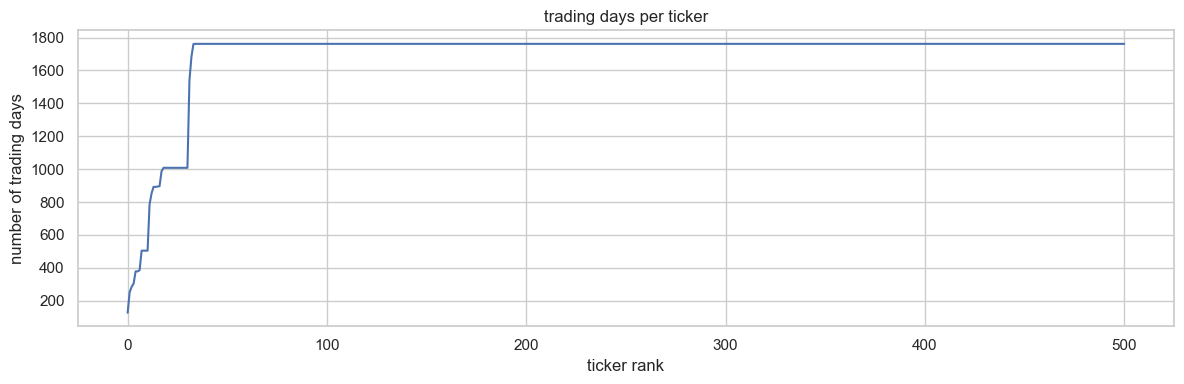

min days: 126 | max days: 1762
tickers with fewer than 1000 days: 18


In [24]:
# checking how many trading days each ticker has — should be roughly equal
days_per_ticker = prices.groupby('symbol')['date'].count().sort_values()

plt.figure(figsize=(12, 4))
plt.plot(days_per_ticker.values)
plt.title('trading days per ticker')
plt.xlabel('ticker rank')
plt.ylabel('number of trading days')
plt.tight_layout()
plt.show()

print("min days:", days_per_ticker.min(), "| max days:", days_per_ticker.max())
print("tickers with fewer than 1000 days:", (days_per_ticker < 1000).sum())

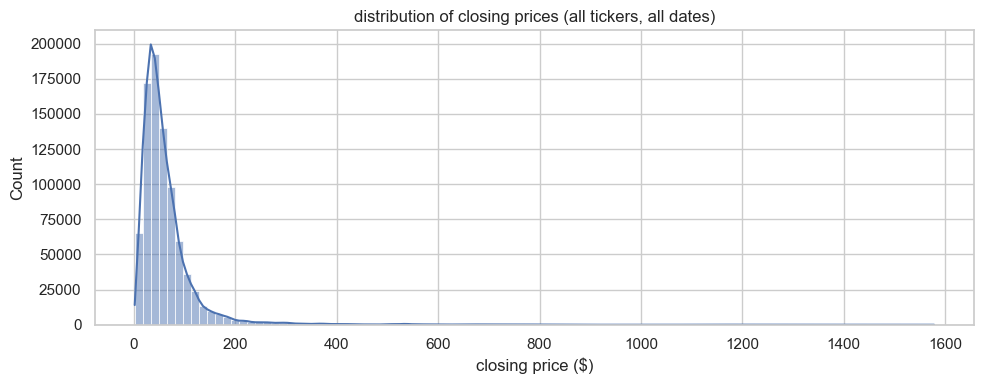

In [25]:
# looking at the overall distribution of closing prices across all tickers
plt.figure(figsize=(10, 4))
sns.histplot(prices['close'], bins=100, kde=True)
plt.title('distribution of closing prices (all tickers, all dates)')
plt.xlabel('closing price ($)')
plt.tight_layout()
plt.show()

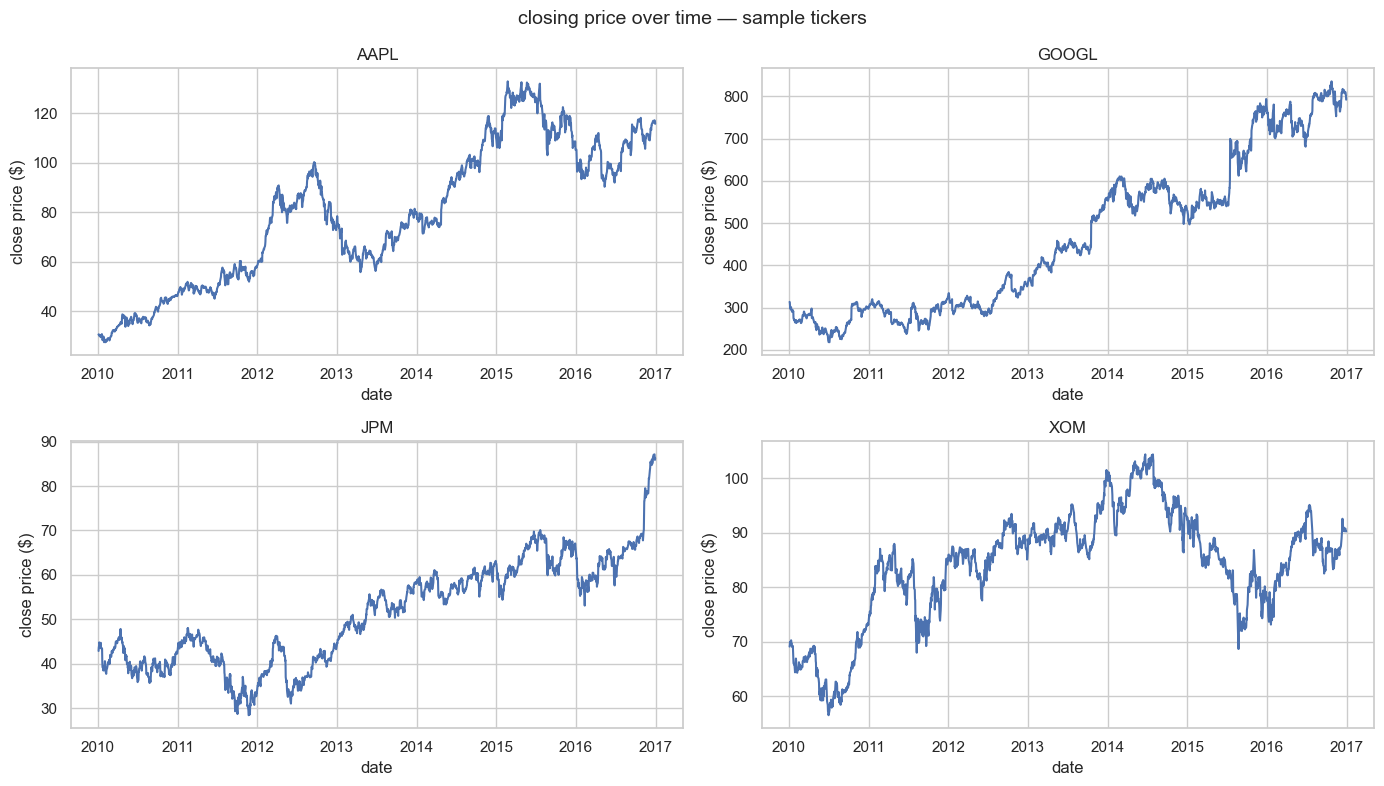

In [26]:
# plotting closing price over time for 4 well-known tickers to sanity check the data
example_tickers = ['AAPL', 'GOOGL', 'JPM', 'XOM']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(example_tickers):
    ticker_data = prices[prices['symbol'] == ticker]
    axes[i].plot(ticker_data['date'], ticker_data['close'])
    axes[i].set_title(ticker)
    axes[i].set_xlabel('date')
    axes[i].set_ylabel('close price ($)')

plt.suptitle('closing price over time — sample tickers', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\kayle\AppData\Local\Temp\ipykernel_13980\2958505435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='Blues_r')


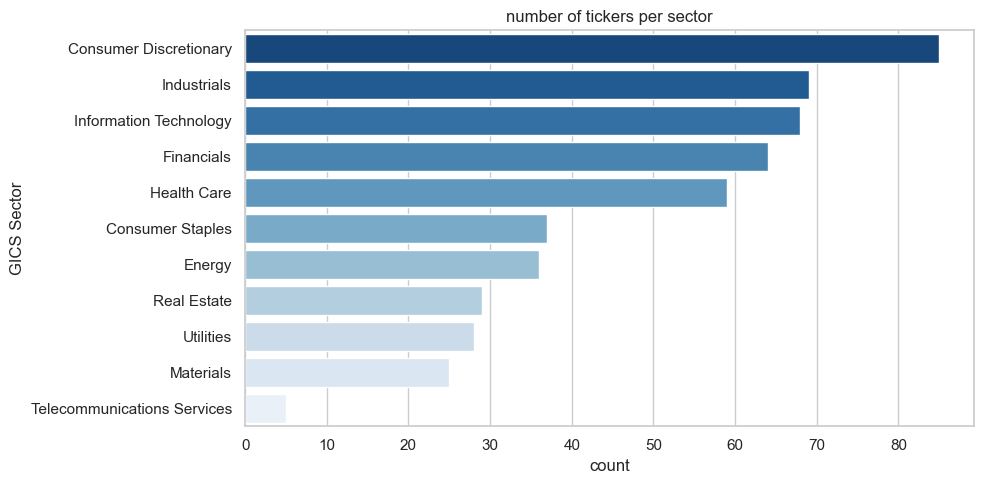

GICS Sector
Consumer Discretionary         85
Industrials                    69
Information Technology         68
Financials                     64
Health Care                    59
Consumer Staples               37
Energy                         36
Real Estate                    29
Utilities                      28
Materials                      25
Telecommunications Services     5
Name: count, dtype: int64


In [27]:
# checking how many tickers fall into each sector
sector_counts = securities['GICS Sector'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='Blues_r')
plt.title('number of tickers per sector')
plt.xlabel('count')
plt.tight_layout()
plt.show()

print(sector_counts)

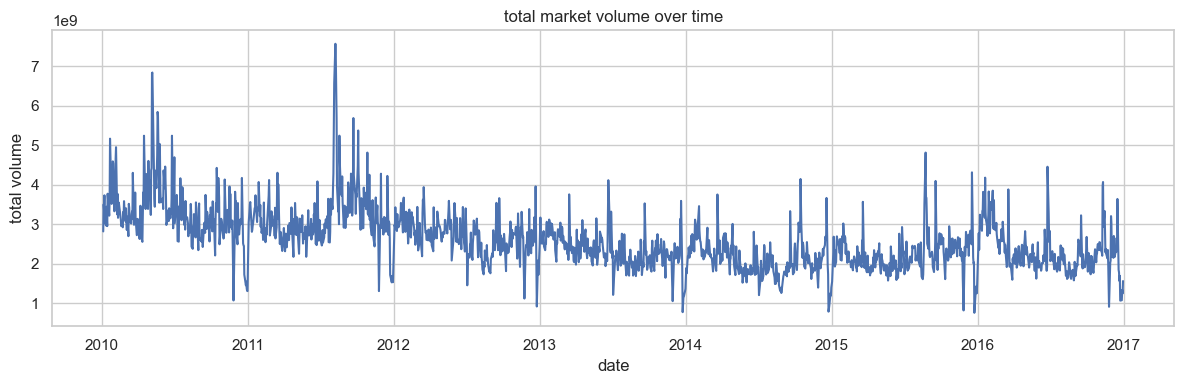

In [28]:
# checking total market volume over time to spot any anomalies
daily_volume = prices.groupby('date')['volume'].sum()

plt.figure(figsize=(12, 4))
plt.plot(daily_volume.index, daily_volume.values)
plt.title('total market volume over time')
plt.xlabel('date')
plt.ylabel('total volume')
plt.tight_layout()
plt.show()

In [29]:
# printing a clean summary of all three datasets before moving to feature engineering
print("=== DATASET SUMMARY ===")
print(f"prices      : {prices.shape[0]:,} rows | {prices['symbol'].nunique()} tickers | {prices['date'].min().date()} to {prices['date'].max().date()}")
print(f"fundamentals: {fundamentals.shape[0]:,} rows | {fundamentals.shape[1]} columns")
print(f"securities  : {securities.shape[0]:,} rows | {securities['GICS Sector'].nunique()} sectors")

=== DATASET SUMMARY ===
prices      : 851,264 rows | 501 tickers | 2010-01-04 to 2016-12-30
fundamentals: 1,781 rows | 79 columns
securities  : 505 rows | 11 sectors


In [30]:
import os
import json
from google.colab import drive, _message, userdata

# pulling credentials from colab secrets
github_token = userdata.get('GITHUB_TOKEN')
github_email = userdata.get('GITHUB_EMAIL')
github_name  = userdata.get('GITHUB_NAME')   # add this secret too — e.g. SidRoy97

# saving the notebook to google drive
notebook_name = '01_data_loading'  # change this per notebook — no extension
notebook_path = f'/content/drive/MyDrive/ML/stock-lens/notebooks/{notebook_name}.ipynb'

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=120)
with open(notebook_path, 'w') as f:
    json.dump(notebook_json['ipynb'], f)
print("saved to drive ✅")

# installing pdf conversion dependencies
os.system('apt-get install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libasound2 -q')
os.system('pip install -q nbconvert[webpdf] playwright')
os.system('playwright install chromium')

# converting notebook to pdf
os.system(f'jupyter nbconvert --to webpdf --allow-chromium-download "{notebook_path}"')
pdf_path = notebook_path.replace('.ipynb', '.pdf')
print("pdf created!!" if os.path.exists(pdf_path) else "pdf creation failed")

# cloning repo if not already present
repo_path = '/content/stock-lens'
if not os.path.exists(repo_path):
    os.system(f'git clone https://github.com/SidRoy97/stock-lens.git {repo_path}')

# creating notebooks folder if missing
os.makedirs(f'{repo_path}/notebooks', exist_ok=True)

# copying notebook and pdf into repo
os.system(f'cp "{notebook_path}" "{repo_path}/notebooks/{notebook_name}.ipynb"')
if os.path.exists(pdf_path):
    os.system(f'cp "{pdf_path}" "{repo_path}/notebooks/{notebook_name}.pdf"')

# configuring git with user credentials
os.system(f'git -C {repo_path} config user.email "{github_email}"')
os.system(f'git -C {repo_path} config user.name "{github_name}"')
os.system(f'git -C {repo_path} add notebooks/')

commit = os.popen(f'git -C {repo_path} commit -m "update {notebook_name} notebook and pdf" 2>&1').read()
print("commit:", commit)

# pushing to github
remote = f'https://{github_token}@github.com/SidRoy97/stock-lens.git'
push   = os.popen(f'git -C {repo_path} push {remote} main 2>&1').read()
print("push:", push)

ModuleNotFoundError: No module named 'google.colab'